# 👤 M3 — Complete Feature Engineering & Classification
**Full pipeline: raw data → 30+ features → 4 models → best result**

Upload `train.csv` via the Files panel before running.

---

## ⚙️ Install & Import

In [ ]:
!pip install xgboost lightgbm category_encoders -q

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import LabelEncoder, StandardScaler, label_binarize
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                              confusion_matrix, log_loss,
                              precision_score, recall_score, f1_score,
                              balanced_accuracy_score, matthews_corrcoef,
                              roc_auc_score, roc_curve, auc,
                              average_precision_score, precision_recall_curve)
from xgboost import XGBClassifier
import lightgbm as lgb
import category_encoders as ce

plt.rcParams['figure.dpi'] = 120
sns.set_style('whitegrid')
print('✅ All libraries loaded!')

## 📂 Load Data
Upload `train.csv` via Files panel (left sidebar), then run.

In [ ]:
df_raw = pd.read_csv('train.csv', parse_dates=['Dates'])
print(f'Shape: {df_raw.shape}')
df_raw.head(3)

Shape: (878049, 9)


,Dates,Category,Descript,DayOfWeek,PdDistrict,Resolution,Address,X,Y
0,2015-05-13 23:53:00,WARRANTS,WARRANT ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
1,2015-05-13 23:53:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",OAK ST / LAGUNA ST,-122.425892,37.774599
2,2015-05-13 23:33:00,OTHER OFFENSES,TRAFFIC VIOLATION ARREST,Wednesday,NORTHERN,"ARREST, BOOKED",VANNESS AV / GREENWICH ST,-122.424363,37.800414


## 🧹 Data Cleaning

In [ ]:
df = df_raw.copy()

# Standardize text
for col in ['Category', 'PdDistrict', 'DayOfWeek', 'Address']:
    df[col] = df[col].str.strip().str.upper()

# Remove geographic outliers
before = len(df)
df = df[df['X'].between(-122.55, -122.33) & df['Y'].between(37.65, 37.85)]
print(f'Removed {before - len(df):,} geographic outliers')

# Drop duplicates
before = len(df)
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f'Removed {before - len(df):,} duplicates')
print(f'Clean shape: {df.shape}')

Removed 67 geographic outliers
Removed 2,323 duplicates
Clean shape: (875659, 9)


## 🔧 Feature Engineering
### Part 1 — Time Features

In [ ]:
df_ml = df.copy()

# ── Basic time ───────────────────────────────────────────────
df_ml['Hour']       = df_ml['Dates'].dt.hour
df_ml['Minute']     = df_ml['Dates'].dt.minute
df_ml['Month']      = df_ml['Dates'].dt.month
df_ml['Year']       = df_ml['Dates'].dt.year
df_ml['DayOfMonth'] = df_ml['Dates'].dt.day
df_ml['DayOfYear']  = df_ml['Dates'].dt.dayofyear
df_ml['WeekOfYear'] = df_ml['Dates'].dt.isocalendar().week.astype(int)
df_ml['Quarter']    = df_ml['Dates'].dt.quarter

# ── Season ───────────────────────────────────────────────────
df_ml['Season'] = df_ml['Month'].map({
    12:0,1:0,2:0,   # Winter
    3:1,4:1,5:1,    # Spring
    6:2,7:2,8:2,    # Summer
    9:3,10:3,11:3   # Fall
})

# ── Binary time flags ────────────────────────────────────────
df_ml['IsWeekend']  = df_ml['DayOfWeek'].isin(['SATURDAY','SUNDAY']).astype(int)
df_ml['IsNight']    = ((df_ml['Hour'] >= 22) | (df_ml['Hour'] <= 5)).astype(int)
df_ml['IsLateNight']= (df_ml['Hour'].between(0, 3)).astype(int)
df_ml['IsMorning']  = (df_ml['Hour'].between(6, 11)).astype(int)
df_ml['IsAfternoon']= (df_ml['Hour'].between(12, 17)).astype(int)
df_ml['IsEvening']  = (df_ml['Hour'].between(18, 21)).astype(int)
df_ml['IsRushHour'] = (df_ml['Hour'].isin(range(7,10)) |
                       df_ml['Hour'].isin(range(16,20))).astype(int)
df_ml['IsBusinessHours'] = (df_ml['Hour'].between(9,17) &
                             (df_ml['IsWeekend'] == 0)).astype(int)

# ── Cyclical encoding (preserves wrap-around) ────────────────
df_ml['HourSin']    = np.sin(2 * np.pi * df_ml['Hour']       / 24)
df_ml['HourCos']    = np.cos(2 * np.pi * df_ml['Hour']       / 24)
df_ml['MonthSin']   = np.sin(2 * np.pi * df_ml['Month']      / 12)
df_ml['MonthCos']   = np.cos(2 * np.pi * df_ml['Month']      / 12)
df_ml['DowSin']     = np.sin(2 * np.pi * df_ml['Dates'].dt.dayofweek / 7)
df_ml['DowCos']     = np.cos(2 * np.pi * df_ml['Dates'].dt.dayofweek / 7)
df_ml['DaySin']     = np.sin(2 * np.pi * df_ml['DayOfYear']  / 365)
df_ml['DayCos']     = np.cos(2 * np.pi * df_ml['DayOfYear']  / 365)

print('✅ Time features done —', df_ml.shape[1], 'columns so far')

✅ Time features done — 34 columns so far


### Part 2 — Address Features

In [ ]:
# ── Block vs Intersection ────────────────────────────────────
df_ml['IsBlock']        = df_ml['Address'].str.contains('BLOCK').astype(int)
df_ml['IsIntersection'] = df_ml['Address'].str.contains('/').astype(int)

# ── Extract street number ────────────────────────────────────
def extract_street_num(addr):
    try:
        first = addr.split()[0]
        return int(first) if first.isdigit() else 0
    except:
        return 0

df_ml['StreetNum'] = df_ml['Address'].apply(extract_street_num)
df_ml['StreetNumBin'] = pd.cut(
    df_ml['StreetNum'],
    bins=[-1, 0, 500, 1000, 2000, 5000, 99999],
    labels=[0,1,2,3,4,5]
).astype(int)

# ── Extract primary street name ──────────────────────────────
def extract_street_name(addr):
    try:
        parts = addr.split()
        start = 1 if parts[0].isdigit() else 0
        if 'BLOCK' in parts:
            start = parts.index('BLOCK') + 2
        return ' '.join(parts[start:start+2])
    except:
        return 'UNKNOWN'

df_ml['StreetName'] = df_ml['Address'].apply(extract_street_name)

# ── Frequency encode street (crime hotspot density) ──────────
street_freq = df_ml['StreetName'].value_counts().to_dict()
df_ml['StreetFreq'] = df_ml['StreetName'].map(street_freq)

# ── Label encode street name ─────────────────────────────────
le_street = LabelEncoder()
df_ml['Street_enc'] = le_street.fit_transform(df_ml['StreetName'])

print(f'Unique streets     : {df_ml["StreetName"].nunique():,}')
print(f'IsBlock %          : {df_ml["IsBlock"].mean()*100:.1f}%')
print(f'IsIntersection %   : {df_ml["IsIntersection"].mean()*100:.1f}%')
print('✅ Address features done —', df_ml.shape[1], 'columns so far')

Unique streets     : 2,019
IsBlock %          : 70.3%
IsIntersection %   : 29.7%
✅ Address features done — 41 columns so far


### Part 3 — Location & Spatial Features

In [ ]:
# ── Coordinate binning ───────────────────────────────────────
df_ml['X_round2'] = df_ml['X'].round(2)
df_ml['Y_round2'] = df_ml['Y'].round(2)
df_ml['X_round3'] = df_ml['X'].round(3)
df_ml['Y_round3'] = df_ml['Y'].round(3)

# ── Distance from city center (Union Square) ─────────────────
cx, cy = -122.4074, 37.7849
df_ml['DistCenter'] = np.sqrt((df_ml['X'] - cx)**2 + (df_ml['Y'] - cy)**2)

# ── Grid cell (coarse spatial bin) ───────────────────────────
df_ml['GridX'] = ((df_ml['X'] - df_ml['X'].min()) / 0.01).astype(int)
df_ml['GridY'] = ((df_ml['Y'] - df_ml['Y'].min()) / 0.01).astype(int)

# ── Crime density per coordinate bin ─────────────────────────
coord_freq = df_ml.groupby(['X_round2','Y_round2']).size().to_dict()
df_ml['CoordFreq'] = df_ml.set_index(['X_round2','Y_round2']).index.map(coord_freq).values

print('✅ Location features done —', df_ml.shape[1], 'columns so far')

✅ Location features done — 49 columns so far


### Part 4 — Categorical Encoding

In [ ]:
# ── Label encode district and day ────────────────────────────
le_district = LabelEncoder()
le_day      = LabelEncoder()
le_target   = LabelEncoder()

df_ml['District_enc']  = le_district.fit_transform(df_ml['PdDistrict'])
df_ml['DayOfWeek_enc'] = le_day.fit_transform(df_ml['DayOfWeek'])
df_ml['Target']        = le_target.fit_transform(df_ml['Category'])

# ── Frequency encoding for district ─────────────────────────
district_freq = df_ml['PdDistrict'].value_counts(normalize=True).to_dict()
df_ml['DistrictRate'] = df_ml['PdDistrict'].map(district_freq)

# ── Interaction features (cross-features) ────────────────────
# These capture compound patterns the model can't learn alone
df_ml['District_Hour']      = df_ml['District_enc'] * 100 + df_ml['Hour']
df_ml['District_DayOfWeek'] = df_ml['District_enc'] * 10  + df_ml['DayOfWeek_enc']
df_ml['Hour_DayOfWeek']     = df_ml['Hour']          * 10  + df_ml['DayOfWeek_enc']
df_ml['District_IsNight']   = df_ml['District_enc'] * 2   + df_ml['IsNight']
df_ml['District_IsWeekend'] = df_ml['District_enc'] * 2   + df_ml['IsWeekend']
df_ml['Street_Hour']        = df_ml['Street_enc']    * 100 + df_ml['Hour']

print('✅ Categorical encoding done —', df_ml.shape[1], 'columns so far')

✅ Categorical encoding done — 59 columns so far


### Part 5 — Define Final Feature Set

In [ ]:
FEATURES = [
    # ── Time
    'Hour', 'Minute', 'Month', 'Year', 'DayOfMonth',
    'DayOfYear', 'WeekOfYear', 'Quarter', 'Season',
    # ── Binary flags
    'IsWeekend', 'IsNight', 'IsLateNight', 'IsMorning',
    'IsAfternoon', 'IsEvening', 'IsRushHour', 'IsBusinessHours',
    # ── Cyclical
    'HourSin', 'HourCos', 'MonthSin', 'MonthCos',
    'DowSin', 'DowCos', 'DaySin', 'DayCos',
    # ── Location
    'X', 'Y', 'DistCenter', 'CoordFreq',
    'X_round2', 'Y_round2', 'X_round3', 'Y_round3',
    'GridX', 'GridY',
    # ── Address
    'IsBlock', 'IsIntersection', 'StreetNum', 'StreetNumBin',
    'Street_enc', 'StreetFreq',
    # ── District
    'District_enc', 'DayOfWeek_enc', 'DistrictRate',
    # ── Interactions
    'District_Hour', 'District_DayOfWeek', 'Hour_DayOfWeek',
    'District_IsNight', 'District_IsWeekend', 'Street_Hour',
]

print(f'Total features: {len(FEATURES)}')
print(f'Features: {FEATURES}')

Total features: 50
Features: ['Hour', 'Minute', 'Month', 'Year', 'DayOfMonth', 'DayOfYear', 'WeekOfYear', 'Quarter', 'Season', 'IsWeekend', 'IsNight', 'IsLateNight', 'IsMorning', 'IsAfternoon', 'IsEvening', 'IsRushHour', 'IsBusinessHours', 'HourSin', 'HourCos', 'MonthSin', 'MonthCos', 'DowSin', 'DowCos', 'DaySin', 'DayCos', 'X', 'Y', 'DistCenter', 'CoordFreq', 'X_round2', 'Y_round2', 'X_round3', 'Y_round3', 'GridX', 'GridY', 'IsBlock', 'IsIntersection', 'StreetNum', 'StreetNumBin', 'Street_enc', 'StreetFreq', 'District_enc', 'DayOfWeek_enc', 'DistrictRate', 'District_Hour', 'District_DayOfWeek', 'Hour_DayOfWeek', 'District_IsNight', 'District_IsWeekend', 'Street_Hour']


## ✂️ Train / Test Split
> Using top 10 crime categories for feasibility. Stratified split preserves class balance.

In [ ]:
TOP_N = 10
top_cats = df_ml['Category'].value_counts().head(TOP_N).index.tolist()
df_clf   = df_ml[df_ml['Category'].isin(top_cats)].copy()
df_clf['Target'] = le_target.fit_transform(df_clf['Category'])

X_all = df_clf[FEATURES]
y_all = df_clf['Target']

X_train, X_test, y_train, y_test = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42, stratify=y_all)

class_names = le_target.inverse_transform(sorted(y_all.unique()))

# Pick 2 most frequent + 3 least frequent classes in the TEST split for PR curves.
_test_counts = y_test.value_counts().sort_values(ascending=False)
_head = _test_counts.head(2).index.astype(int).tolist()
_tail = _test_counts.tail(3).index.astype(int).tolist()
pr_plot_class_indices = []
for cls in _head + _tail:
    if cls not in pr_plot_class_indices:
        pr_plot_class_indices.append(cls)
pr_plot_class_indices = pr_plot_class_indices[:5]
print('PR curve classes (test-frequency head/tail):')
for c in pr_plot_class_indices:
    print(f'  - {class_names[c]} (idx={c}, n={int(_test_counts[c])})')

def evaluate_model(model_name, y_true, y_pred, y_prob):
    n_classes = y_prob.shape[1]
    y_true_bin = label_binarize(y_true, classes=np.arange(n_classes))

    metrics = {
        'Accuracy': accuracy_score(y_true, y_pred),
        'Balanced Accuracy': balanced_accuracy_score(y_true, y_pred),
        'Log-Loss': log_loss(y_true, y_prob),
        'Precision (weighted)': precision_score(y_true, y_pred, average='weighted', zero_division=0),
        'Recall (weighted)': recall_score(y_true, y_pred, average='weighted', zero_division=0),
        'F1 Score (weighted)': f1_score(y_true, y_pred, average='weighted', zero_division=0),
        'Precision (macro)': precision_score(y_true, y_pred, average='macro', zero_division=0),
        'Recall (macro)': recall_score(y_true, y_pred, average='macro', zero_division=0),
        'F1 Score (macro)': f1_score(y_true, y_pred, average='macro', zero_division=0),
        'MCC': matthews_corrcoef(y_true, y_pred),
        'ROC-AUC OvR (macro)': roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='macro'),
        'ROC-AUC OvR (weighted)': roc_auc_score(y_true_bin, y_prob, multi_class='ovr', average='weighted'),
        'PR-AUC OvR (macro)': average_precision_score(y_true_bin, y_prob, average='macro'),
        'PR-AUC OvR (weighted)': average_precision_score(y_true_bin, y_prob, average='weighted'),
    }

    print(f"\n📈 {model_name} - Extended Metrics")
    print(f"   ROC-AUC OvR (macro)   : {metrics['ROC-AUC OvR (macro)']:.4f}")
    print(f"   ROC-AUC OvR (weighted): {metrics['ROC-AUC OvR (weighted)']:.4f}")
    print(f"   PR-AUC OvR (macro)    : {metrics['PR-AUC OvR (macro)']:.4f}")
    print(f"   PR-AUC OvR (weighted) : {metrics['PR-AUC OvR (weighted)']:.4f}")
    print(f"   Balanced Accuracy     : {metrics['Balanced Accuracy']:.4f}")
    print(f"   MCC                   : {metrics['MCC']:.4f}")

    return metrics

print(f'Train : {len(X_train):,}')
print(f'Test  : {len(X_test):,}')
print(f'Classes ({TOP_N}): {list(top_cats)}')

Train : 585,035
Test  : 146,259
Classes (10): ['LARCENY/THEFT', 'OTHER OFFENSES', 'NON-CRIMINAL', 'ASSAULT', 'DRUG/NARCOTIC', 'VEHICLE THEFT', 'VANDALISM', 'WARRANTS', 'BURGLARY', 'SUSPICIOUS OCC']


## 🤖 Model 1 — Logistic Regression (Baseline)

In [ ]:
scaler     = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print('Training Logistic Regression...')
lr = LogisticRegression(max_iter=1000, C=1.0, random_state=42, n_jobs=-1)
lr.fit(X_train_sc, y_train)
y_pred_lr = lr.predict(X_test_sc)
prob_lr   = lr.predict_proba(X_test_sc)

metrics_lr = evaluate_model('Logistic Regression', y_test, y_pred_lr, prob_lr)
acc_lr = metrics_lr['Accuracy']
ll_lr  = metrics_lr['Log-Loss']
print(f'\n✅ Accuracy : {acc_lr:.4f} ({acc_lr*100:.2f}%)')
print(f'   Log-Loss : {ll_lr:.4f}')
print(f"   ROC-AUC (macro): {metrics_lr['ROC-AUC OvR (macro)']:.4f}")
print(f"   PR-AUC (macro) : {metrics_lr['PR-AUC OvR (macro)']:.4f}")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

Training Logistic Regression...

📈 Logistic Regression - Extended Metrics
   ROC-AUC OvR (macro)   : 0.6763
   ROC-AUC OvR (weighted): 0.6688
   Balanced Accuracy     : 0.1724
   MCC                   : 0.1389

✅ Accuracy : 0.2951 (29.51%)
   Log-Loss : 1.9868
   ROC-AUC (macro): 0.6763
                precision    recall  f1-score   support

       ASSAULT       0.21      0.10      0.13     15362
      BURGLARY       0.17      0.01      0.02      7320
 DRUG/NARCOTIC       0.31      0.25      0.28     10784
 LARCENY/THEFT       0.31      0.75      0.44     34861
  NON-CRIMINAL       0.21      0.03      0.06     18382
OTHER OFFENSES       0.29      0.41      0.34     25189
SUSPICIOUS OCC       0.00      0.00      0.00      6278
     VANDALISM       0.21      0.00      0.00      8916
 VEHICLE THEFT       0.27      0.17      0.21     10740
      WARRANTS       0.00      0.00      0.00      8427

      accuracy                           0.30    146259
     macro avg       0.20      0.17   

## 🤖 Model 2 — Random Forest

In [ ]:
print('Training Random Forest...')
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=20,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features='sqrt',
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)
prob_rf   = rf.predict_proba(X_test)

metrics_rf = evaluate_model('Random Forest', y_test, y_pred_rf, prob_rf)
acc_rf = metrics_rf['Accuracy']
ll_rf  = metrics_rf['Log-Loss']
print(f'\n✅ Accuracy : {acc_rf:.4f} ({acc_rf*100:.2f}%)')
print(f'   Log-Loss : {ll_rf:.4f}')
print(f"   ROC-AUC (macro): {metrics_rf['ROC-AUC OvR (macro)']:.4f}")
print(f"   PR-AUC (macro) : {metrics_rf['PR-AUC OvR (macro)']:.4f}")
print(classification_report(y_test, y_pred_rf, target_names=class_names))

Training Random Forest...

📈 Random Forest - Extended Metrics
   ROC-AUC OvR (macro)   : 0.7587
   ROC-AUC OvR (weighted): 0.7591
   Balanced Accuracy     : 0.2703
   MCC                   : 0.2620

✅ Accuracy : 0.3819 (38.19%)
   Log-Loss : 1.7817
   ROC-AUC (macro): 0.7587
                precision    recall  f1-score   support

       ASSAULT       0.30      0.28      0.29     15362
      BURGLARY       0.27      0.08      0.12      7320
 DRUG/NARCOTIC       0.41      0.46      0.43     10784
 LARCENY/THEFT       0.41      0.75      0.53     34861
  NON-CRIMINAL       0.32      0.23      0.27     18382
OTHER OFFENSES       0.37      0.43      0.40     25189
SUSPICIOUS OCC       0.11      0.01      0.02      6278
     VANDALISM       0.23      0.04      0.07      8916
 VEHICLE THEFT       0.52      0.38      0.44     10740
      WARRANTS       0.21      0.05      0.08      8427

      accuracy                           0.38    146259
     macro avg       0.31      0.27      0.26    1

## 🤖 Model 3 — XGBoost

In [ ]:
print('Training XGBoost...')
xgb = XGBClassifier(
    n_estimators=300,
    max_depth=8,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    reg_alpha=0.1,
    reg_lambda=1.0,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1,
    verbosity=0
)
xgb.fit(X_train, y_train,
        eval_set=[(X_test, y_test)],
        verbose=False)
y_pred_xgb = xgb.predict(X_test)
prob_xgb   = xgb.predict_proba(X_test)

metrics_xgb = evaluate_model('XGBoost', y_test, y_pred_xgb, prob_xgb)
acc_xgb = metrics_xgb['Accuracy']
ll_xgb  = metrics_xgb['Log-Loss']
print(f'\n✅ Accuracy : {acc_xgb:.4f} ({acc_xgb*100:.2f}%)')
print(f'   Log-Loss : {ll_xgb:.4f}')
print(f"   ROC-AUC (macro): {metrics_xgb['ROC-AUC OvR (macro)']:.4f}")
print(f"   PR-AUC (macro) : {metrics_xgb['PR-AUC OvR (macro)']:.4f}")
print(classification_report(y_test, y_pred_xgb, target_names=class_names))

Training XGBoost...

📈 XGBoost - Extended Metrics
   ROC-AUC OvR (macro)   : 0.7621
   ROC-AUC OvR (weighted): 0.7623
   Balanced Accuracy     : 0.2554
   MCC                   : 0.2507

✅ Accuracy : 0.3737 (37.37%)
   Log-Loss : 1.7777
   ROC-AUC (macro): 0.7621
                precision    recall  f1-score   support

       ASSAULT       0.27      0.22      0.24     15362
      BURGLARY       0.26      0.08      0.12      7320
 DRUG/NARCOTIC       0.40      0.46      0.43     10784
 LARCENY/THEFT       0.40      0.76      0.53     34861
  NON-CRIMINAL       0.33      0.20      0.24     18382
OTHER OFFENSES       0.37      0.47      0.42     25189
SUSPICIOUS OCC       0.17      0.00      0.01      6278
     VANDALISM       0.26      0.02      0.04      8916
 VEHICLE THEFT       0.38      0.32      0.35     10740
      WARRANTS       0.24      0.02      0.04      8427

      accuracy                           0.37    146259
     macro avg       0.31      0.26      0.24    146259
  weig

## 🤖 Model 4 — LightGBM (Best Expected)

In [ ]:
print('Training LightGBM...')
lgbm = lgb.LGBMClassifier(
    n_estimators=500,
    max_depth=10,
    learning_rate=0.05,
    num_leaves=63,
    subsample=0.8,
    colsample_bytree=0.8,
    min_child_samples=20,
    reg_alpha=0.1,
    reg_lambda=0.1,
    random_state=42,
    n_jobs=-1,
    verbose=-1
)
lgbm.fit(
    X_train, y_train,
    eval_set=[(X_test, y_test)],
    callbacks=[lgb.early_stopping(50, verbose=False),
               lgb.log_evaluation(100)]
)
y_pred_lgbm = lgbm.predict(X_test)
prob_lgbm   = lgbm.predict_proba(X_test)

metrics_lgbm = evaluate_model('LightGBM', y_test, y_pred_lgbm, prob_lgbm)
acc_lgbm = metrics_lgbm['Accuracy']
ll_lgbm  = metrics_lgbm['Log-Loss']
print(f'\n✅ Accuracy : {acc_lgbm:.4f} ({acc_lgbm*100:.2f}%)')
print(f'   Log-Loss : {ll_lgbm:.4f}')
print(f"   ROC-AUC (macro): {metrics_lgbm['ROC-AUC OvR (macro)']:.4f}")
print(f"   PR-AUC (macro) : {metrics_lgbm['PR-AUC OvR (macro)']:.4f}")
print(classification_report(y_test, y_pred_lgbm, target_names=class_names))

Training LightGBM...
[100]	valid_0's multi_logloss: 1.80797
[200]	valid_0's multi_logloss: 1.79024
[300]	valid_0's multi_logloss: 1.78276
[400]	valid_0's multi_logloss: 1.7775
[500]	valid_0's multi_logloss: 1.77321

📈 LightGBM - Extended Metrics
   ROC-AUC OvR (macro)   : 0.7626
   ROC-AUC OvR (weighted): 0.7631
   Balanced Accuracy     : 0.2602
   MCC                   : 0.2537

✅ Accuracy : 0.3755 (37.55%)
   Log-Loss : 1.7732
   ROC-AUC (macro): 0.7626
                precision    recall  f1-score   support

       ASSAULT       0.27      0.23      0.25     15362
      BURGLARY       0.27      0.10      0.14      7320
 DRUG/NARCOTIC       0.40      0.48      0.44     10784
 LARCENY/THEFT       0.41      0.75      0.53     34861
  NON-CRIMINAL       0.32      0.20      0.25     18382
OTHER OFFENSES       0.37      0.46      0.41     25189
SUSPICIOUS OCC       0.17      0.00      0.01      6278
     VANDALISM       0.26      0.03      0.05      8916
 VEHICLE THEFT       0.38      0.32

## 📊 Model Comparison

In [ ]:
results = pd.DataFrame([
    {'Model': 'Logistic Regression', **metrics_lr},
    {'Model': 'Random Forest', **metrics_rf},
    {'Model': 'XGBoost', **metrics_xgb},
    {'Model': 'LightGBM', **metrics_lgbm},
]).set_index('Model').round(4)

print('Model Comparison (All Evaluation Metrics):')
print(results.to_string())

Model Comparison (All Evaluation Metrics):
                     Accuracy  Balanced Accuracy  Log-Loss  Precision (weighted)  Recall (weighted)  F1 Score (weighted)  Precision (macro)  Recall (macro)  F1 Score (macro)     MCC  ROC-AUC OvR (macro)  ROC-AUC OvR (weighted)
Model                                                                                                                                                                                                                             
Logistic Regression    0.2951             0.1724    1.9868                0.2359             0.2951               0.2211             0.1976          0.1724            0.1478  0.1389               0.6763                  0.6688
Random Forest          0.3819             0.2703    1.7817                0.3462             0.3819               0.3385             0.3150          0.2703            0.2645  0.2620               0.7587                  0.7591
XGBoost                0.3737             0.2554 

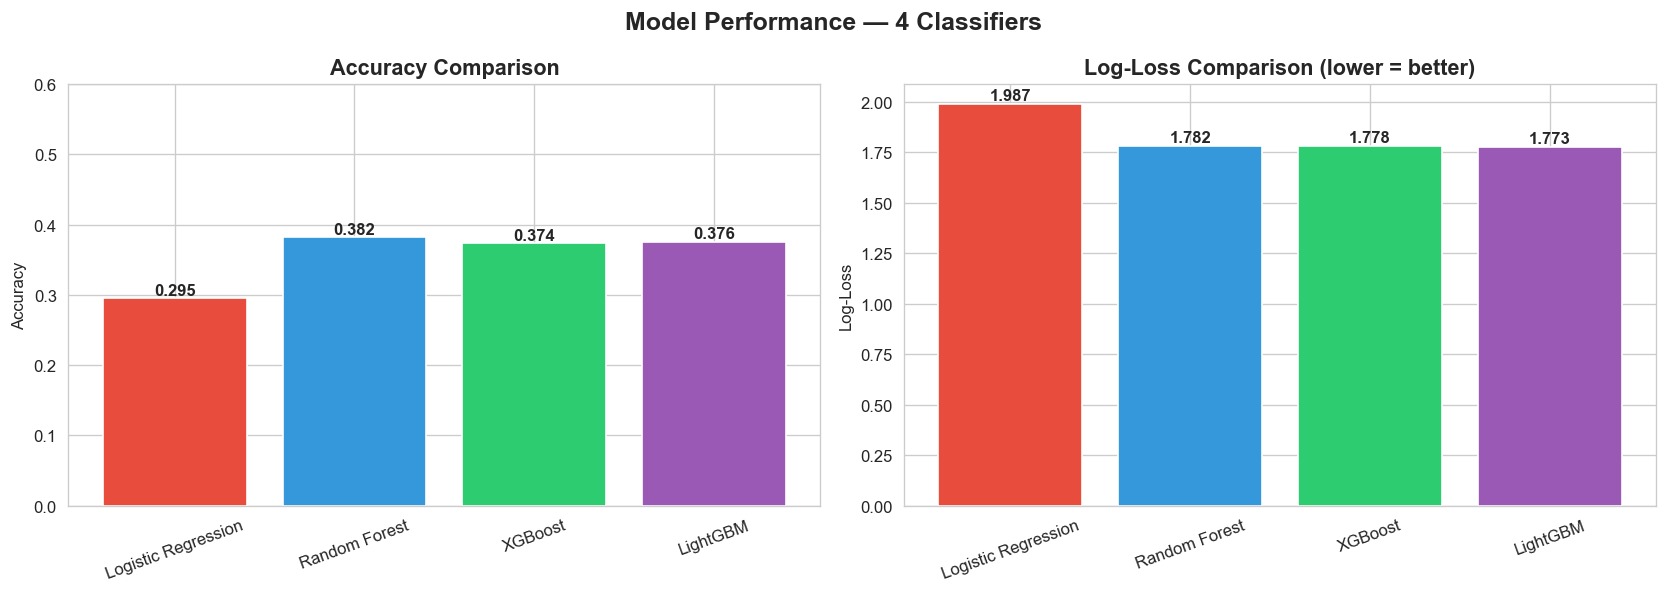

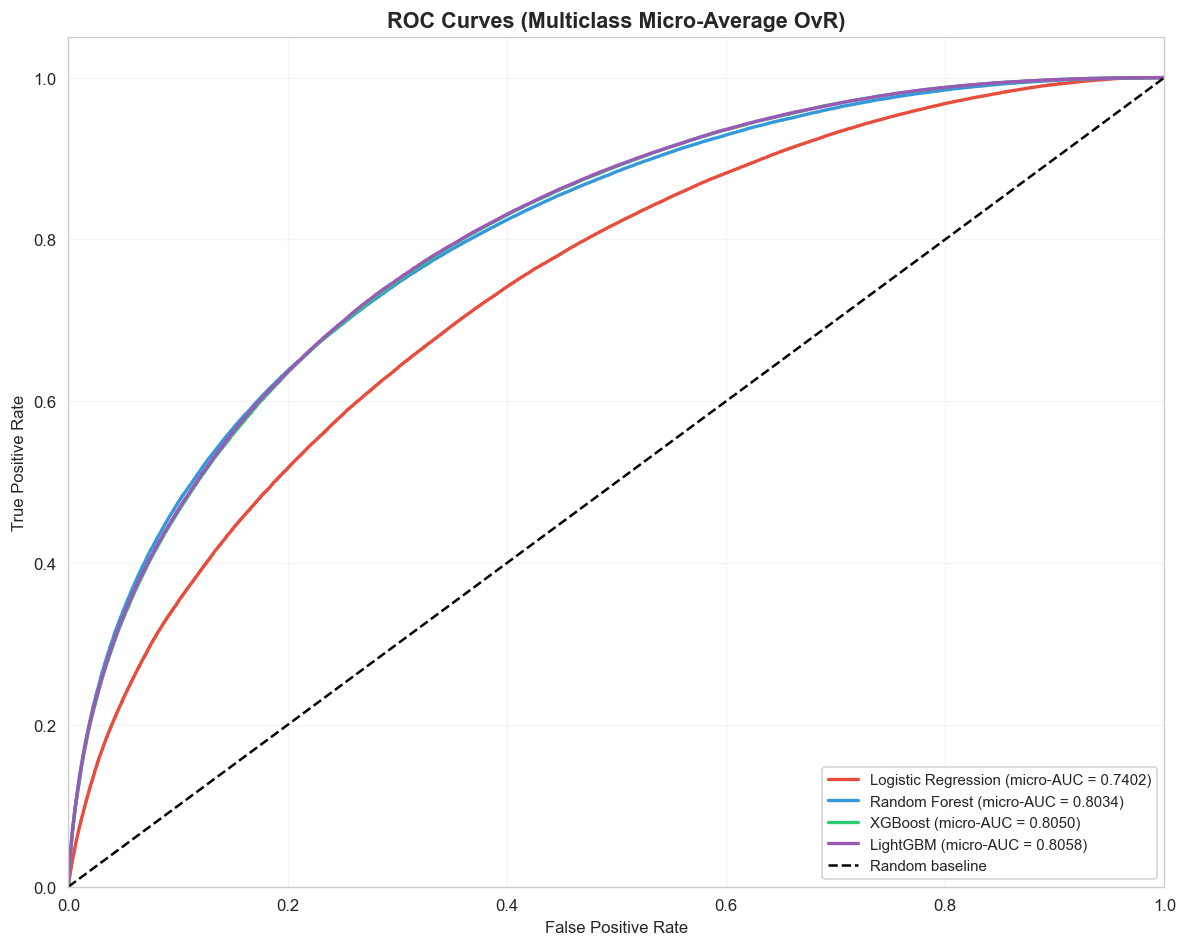

In [ ]:
# ── Bar chart comparison ─────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Accuracy
colors = ['#e74c3c','#3498db','#2ecc71','#9b59b6']
axes[0].bar(results.index, results['Accuracy'], color=colors, edgecolor='white')
axes[0].set_title('Accuracy Comparison', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Accuracy')
axes[0].set_ylim(0, 0.6)
for i, v in enumerate(results['Accuracy']):
    axes[0].text(i, v + 0.005, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[0].tick_params(axis='x', rotation=20)

# Log-Loss (lower is better)
axes[1].bar(results.index, results['Log-Loss'], color=colors, edgecolor='white')
axes[1].set_title('Log-Loss Comparison (lower = better)', fontsize=13, fontweight='bold')
axes[1].set_ylabel('Log-Loss')
for i, v in enumerate(results['Log-Loss']):
    axes[1].text(i, v + 0.02, f'{v:.3f}', ha='center', fontsize=10, fontweight='bold')
axes[1].tick_params(axis='x', rotation=20)

plt.suptitle('Model Performance — 4 Classifiers', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('m3_model_comparison_final.png', bbox_inches='tight')
plt.show()

# ── ROC-AUC curves (micro-average, one-vs-rest) ─────────────
y_test_bin = label_binarize(y_test, classes=np.arange(len(class_names)))

roc_sources = [
    ('Logistic Regression', prob_lr, '#e74c3c'),
    ('Random Forest', prob_rf, '#3498db'),
    ('XGBoost', prob_xgb, '#2ecc71'),
    ('LightGBM', prob_lgbm, '#9b59b6'),
]

plt.figure(figsize=(10, 8))
for name, probs, color in roc_sources:
    fpr, tpr, _ = roc_curve(y_test_bin.ravel(), probs.ravel())
    roc_auc_micro = auc(fpr, tpr)
    plt.plot(
        fpr, tpr,
        color=color,
        linewidth=2,
        label=f'{name} (micro-AUC = {roc_auc_micro:.4f})'
    )

plt.plot([0, 1], [0, 1], 'k--', linewidth=1.5, label='Random baseline')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curves (Multiclass Micro-Average OvR)', fontsize=13, fontweight='bold')
plt.legend(loc='lower right', fontsize=9)
plt.grid(alpha=0.2)
plt.tight_layout()
plt.savefig('m3_roc_auc_curves_final.png', bbox_inches='tight')
plt.show()

# ── PR curves (per-class OvR) ────────────────────────────────
pr_sources = [
    ('Logistic Regression', prob_lr, '#e74c3c'),
    ('Random Forest', prob_rf, '#3498db'),
    ('XGBoost', prob_xgb, '#2ecc71'),
    ('LightGBM', prob_lgbm, '#9b59b6'),
]

n_pr = len(pr_plot_class_indices)
fig_pr, axes_pr = plt.subplots(1, n_pr, figsize=(4.2 * n_pr, 4.2), squeeze=False)

for ax_idx, cls in enumerate(pr_plot_class_indices):
    ax = axes_pr[0][ax_idx]
    y_bin = (y_test.to_numpy() == cls).astype(int)
    pos_rate = float(y_bin.mean())

    for name, probs, color in pr_sources:
        scores = probs[:, cls]
        prec, rec, _ = precision_recall_curve(y_bin, scores)
        ap = average_precision_score(y_bin, scores)
        ax.plot(rec, prec, color=color, linewidth=2, label=f'{name} (AP={ap:.3f})')

    ax.axhline(pos_rate, color='k', linestyle='--', linewidth=1.2, label=f'Baseline ({pos_rate:.3f})')
    ax.set_title(f'PR — {class_names[cls]}', fontsize=11, fontweight='bold')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_xlim([0.0, 1.0])
    ax.set_ylim([0.0, 1.05])
    ax.grid(alpha=0.2)
    ax.legend(fontsize=7, loc='lower left')

plt.suptitle('Precision–Recall Curves (Selected Classes)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('m3_pr_curves_final.png', bbox_inches='tight')
plt.show()

## 📊 Feature Importance (LightGBM — Best Model)

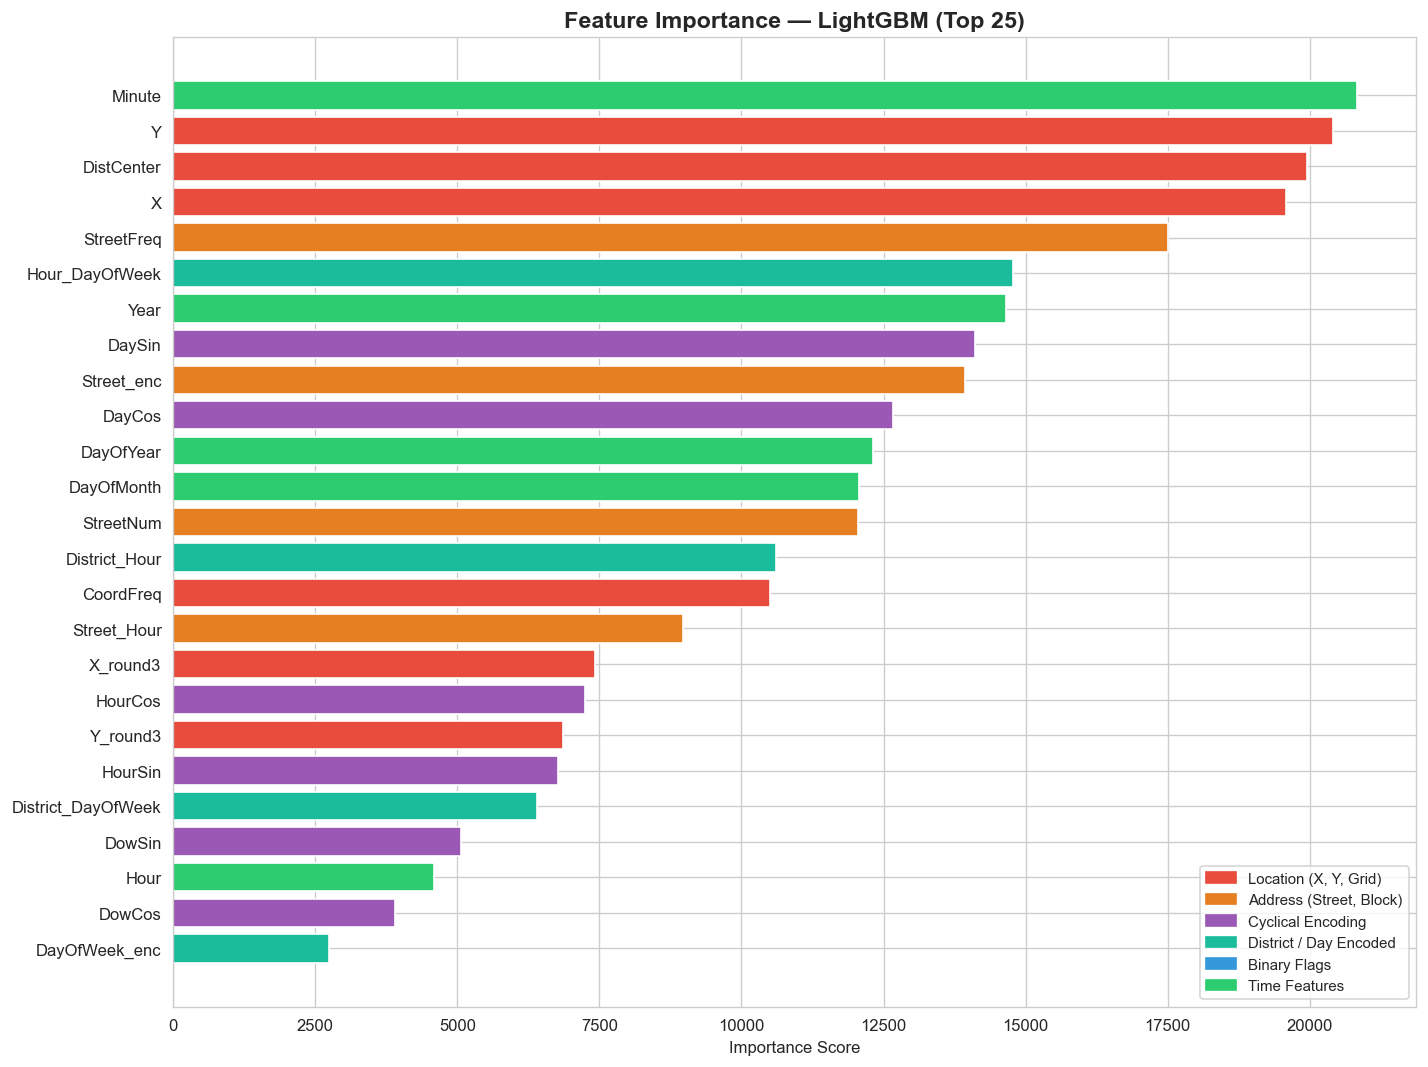

In [ ]:
feat_imp = pd.Series(
    lgbm.feature_importances_,
    index=FEATURES
).sort_values(ascending=False).head(25)

# Color by group
def get_color(f):
    if f in ['X','Y','DistCenter','CoordFreq','X_round2','Y_round2',
              'X_round3','Y_round3','GridX','GridY']:          return '#e74c3c'
    if 'Street' in f or 'Block' in f or 'Intersection' in f\
       or 'StreetNum' in f:                                    return '#e67e22'
    if 'Sin' in f or 'Cos' in f:                              return '#9b59b6'
    if 'District' in f or 'DayOfWeek' in f:                   return '#1abc9c'
    if f.startswith('Is') or f == 'Season':                    return '#3498db'
    return '#2ecc71'

colors = [get_color(f) for f in feat_imp.index]

import matplotlib.patches as mpatches
fig, ax = plt.subplots(figsize=(12, 9))
ax.barh(feat_imp.index[::-1], feat_imp.values[::-1],
        color=colors[::-1], edgecolor='white')
ax.set_title('Feature Importance — LightGBM (Top 25)', fontsize=14, fontweight='bold')
ax.set_xlabel('Importance Score')

legend = [
    mpatches.Patch(color='#e74c3c', label='Location (X, Y, Grid)'),
    mpatches.Patch(color='#e67e22', label='Address (Street, Block)'),
    mpatches.Patch(color='#9b59b6', label='Cyclical Encoding'),
    mpatches.Patch(color='#1abc9c', label='District / Day Encoded'),
    mpatches.Patch(color='#3498db', label='Binary Flags'),
    mpatches.Patch(color='#2ecc71', label='Time Features'),
]
ax.legend(handles=legend, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig('m3_feature_importance_final.png', bbox_inches='tight')
plt.show()

## 📊 Confusion Matrix (Best Model — LightGBM)

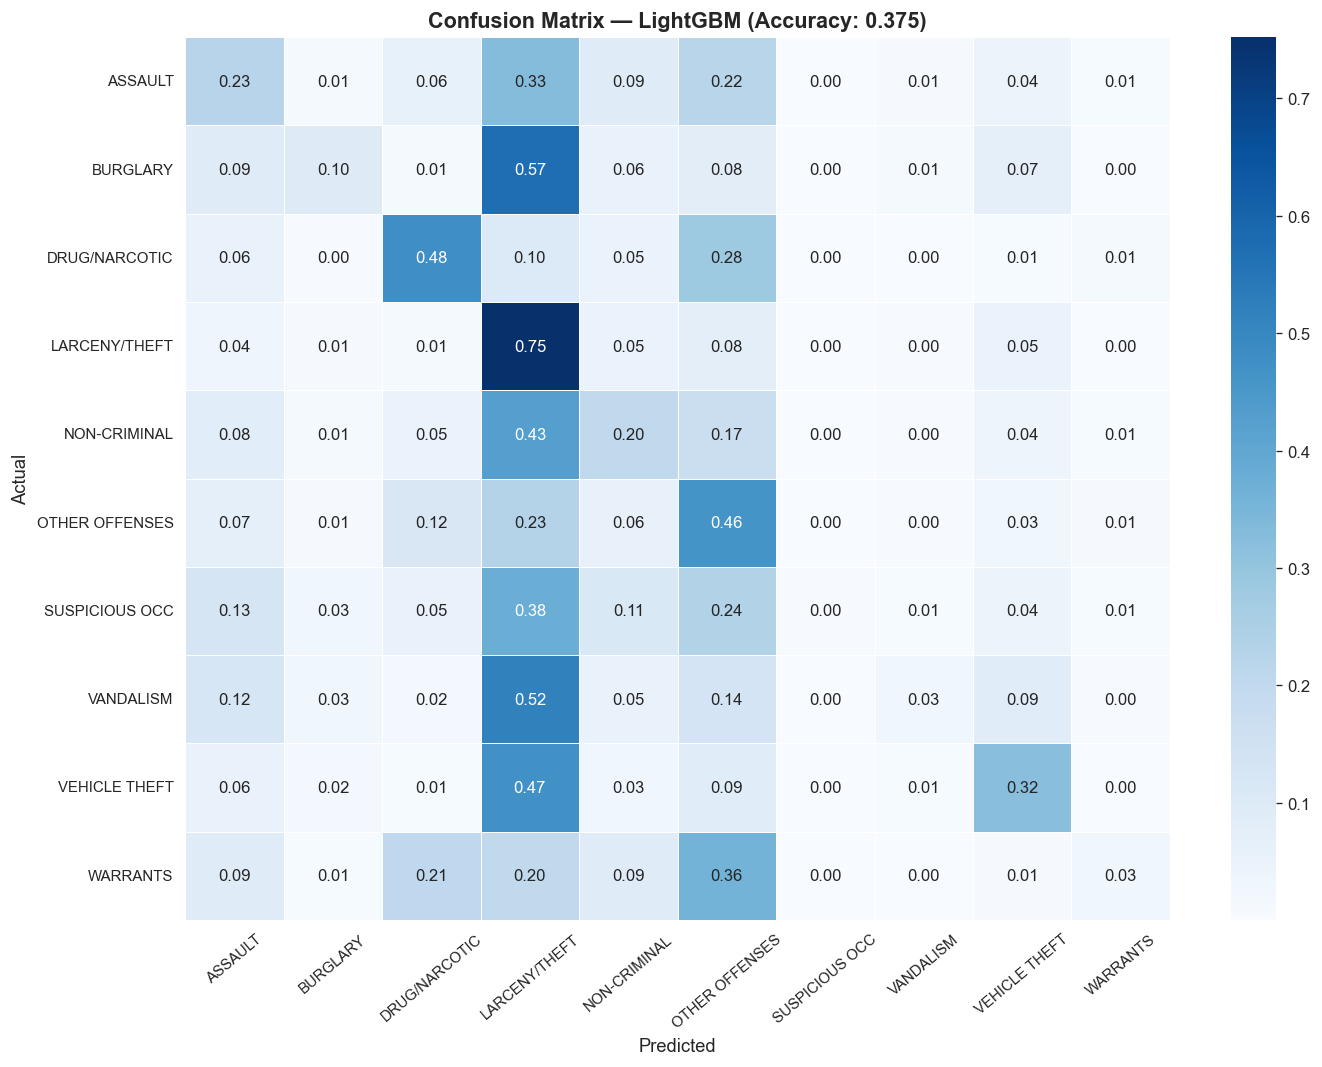

In [ ]:
cm = confusion_matrix(y_test, y_pred_lgbm)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(12, 9))
sns.heatmap(cm_norm, annot=True, fmt='.2f', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names,
            linewidths=0.4, ax=ax)
ax.set_title(f'Confusion Matrix — LightGBM (Accuracy: {acc_lgbm:.3f})',
             fontsize=13, fontweight='bold')
ax.set_xlabel('Predicted', fontsize=11)
ax.set_ylabel('Actual', fontsize=11)
ax.tick_params(axis='x', rotation=40, labelsize=9)
ax.tick_params(axis='y', rotation=0,  labelsize=9)
plt.tight_layout()
plt.savefig('m3_confusion_matrix_final.png', bbox_inches='tight')
plt.show()

## 📦 Save & Download All Outputs

In [ ]:
import os, zipfile
from google.colab import files

results.to_csv('m3_model_results.csv')

outputs = [
    'm3_model_comparison_final.png',
    'm3_roc_auc_curves_final.png',
    'm3_pr_curves_final.png',
    'm3_feature_importance_final.png',
    'm3_confusion_matrix_final.png',
    'm3_model_results.csv',
]

with zipfile.ZipFile('M3_Final_Outputs.zip', 'w') as zf:
    for f in outputs:
        if os.path.exists(f):
            zf.write(f)
            print(f'  ✅ {f}')

files.download('M3_Final_Outputs.zip')
print('\n✅ Done! Check your downloads folder.')

ModuleNotFoundError: No module named 'google'